# 06 · DAU 스파이크 날짜 행동·세그먼트 EDA

**대상:** DAU 봉우리의 신규 기기 — 2026-08-15 44대, 2026-09-04 30대, 2026-09-10 25대. 비교 기준은 나머지 날짜의 신규 기기 257대다.

**분석 단위:** GA4 `user_pseudo_id` 기기. 행동은 각 기기가 처음 관측된 KST 날짜 안에서만 센다.

## 합의한 가설 H2

> 8월 15일의 급증은 해외 무행동 유입이고, 9월 4일과 9월 10일의 급증은 국내 실플레이 유입이다.

**사전 판정 기준:** ① 8/15 해외 비중 ≥60%, ② 8/15 의도적 행동률 ≤30%, ③ 9/4와 9/10 각각 한국 비중 ≥50%, ④ 두 날짜의 행동률이 8/15보다 각각 30%p 이상 높으면 채택한다. 하나라도 어긋나면 기각한다.

**G2 완료 기준:** 모델을 학습하지 않고 행동 깊이·행동 종류·국가·기기·유입·관측시간·D1/D7을 원시 집계와 개별 PNG로 확인하며 작은 표본과 계측 한계를 명시한다.

## 1. 무엇을 행동으로 셌나

자동 수집 이벤트(`first_visit`, `session_start`, `page_view`, `scroll`, `user_engagement`), 재방문 때 자동 발생하는 `login`, 체류 요약, 날씨, 경제 원장 `econ_tx`는 행동이 아니다.

대신 기존 `02_churn_where.ipynb`에서 내부를 확인한 **의도적 행동 허용목록**을 그대로 썼다. 벌목·농사·채집·광산·낚시·상점·제작·건축·NPC·퀘스트·요리·조각·배·안개·반딧불·협동·카페·사진·도감 열기 등이 포함된다.

`tutorial_skip`은 과거에 도움말 닫기와 합쳐 기록된 구간이 있어 행동·온보딩 양쪽에서 제외했다.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import bq, report as R, tracking

SQL = ROOT / 'ml' / 'sql'
OUT = ROOT / 'ml' / 'reports' / 'g2_spike_behavior_2026-09-12'
OUT.mkdir(parents=True, exist_ok=True)
R.setup()
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 40)

ORDER = ['08/15 spike', '09/04 spike', '09/10 spike', 'non-spike']
KO = {'08/15 spike':'8/15', '09/04 spike':'9/4', '09/10 spike':'9/10', 'non-spike':'평시'}

def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z*z/n
    center = (p + z*z/(2*n)) / den
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return center-half, center+half

## 2. 실행 SQL

쿼리 원문을 실행 전에 남긴다. 식별자는 CTE 내부 조인에만 쓰고 최종 결과에서 제거했다. 9월 11일까지의 완전 데이터만 사용한다.

In [2]:
sql_files = ['g2_spike_user_behavior.sql', 'g2_spike_action_reach.sql']
for filename in sql_files:
    text = (SQL / filename).read_text(encoding='utf-8')
    display(Markdown(f'### `{filename}`\n```sql\n{text}\n```'))

### `g2_spike_user_behavior.sql`
```sql
-- G2 spike-day behavior: one anonymous feature row per first-seen GA4 device.
-- The device identifier is used inside CTEs for joins and removed from output.
-- Deliberate actions use the allowlist already audited in 02_churn_where.ipynb;
-- automatic collection, login, ledger, and passive UI events are not actions.
WITH base AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS activity_day,
    event_timestamp,
    user_pseudo_id,
    event_name,
    COALESCE(device.category, '(unknown)') AS device,
    COALESCE(geo.country, '(unknown)') AS country,
    COALESCE(traffic_source.source, '(direct)') AS source,
    COALESCE(traffic_source.medium, '(none)') AS medium
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE user_pseudo_id IS NOT NULL
    AND _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') <= DATE '2026-09-11'
),
first_seen AS (
  SELECT user_pseudo_id, MIN(activity_day) AS first_day
  FROM base
  GROUP BY 1
),
profile AS (
  SELECT
    b.user_pseudo_id,
    ARRAY_AGG(
      STRUCT(b.device AS device, b.country AS country, b.source AS source, b.medium AS medium)
      ORDER BY b.event_timestamp LIMIT 1
    )[OFFSET(0)] AS p
  FROM base b
  GROUP BY 1
),
first_day_events AS (
  SELECT b.*, f.first_day
  FROM base b
  JOIN first_seen f USING (user_pseudo_id)
  WHERE b.activity_day = f.first_day
),
returns AS (
  SELECT
    f.user_pseudo_id,
    LOGICAL_OR(b.activity_day = DATE_ADD(f.first_day, INTERVAL 1 DAY)) AS returned_d1,
    LOGICAL_OR(b.activity_day = DATE_ADD(f.first_day, INTERVAL 7 DAY)) AS returned_d7
  FROM first_seen f
  JOIN base b USING (user_pseudo_id)
  GROUP BY 1
),
features AS (
  SELECT
    e.user_pseudo_id,
    e.first_day,
    CASE
      WHEN e.first_day = DATE '2026-08-15' THEN '08/15 spike'
      WHEN e.first_day = DATE '2026-09-04' THEN '09/04 spike'
      WHEN e.first_day = DATE '2026-09-10' THEN '09/10 spike'
      ELSE 'non-spike'
    END AS cohort,
    p.p.device AS device,
    CASE
      WHEN p.p.country = 'South Korea' THEN 'South Korea'
      WHEN p.p.country = 'United States' THEN 'United States'
      ELSE 'Other'
    END AS country_group,
    CASE
      WHEN LOWER(p.p.source) IN ('(direct)', 'direct')
       AND LOWER(p.p.medium) IN ('(none)', 'none') THEN 'direct / none'
      ELSE 'other acquisition'
    END AS acquisition_group,
    COUNT(*) AS ga4_events,
    TIMESTAMP_DIFF(
      TIMESTAMP_MICROS(MAX(e.event_timestamp)),
      TIMESTAMP_MICROS(MIN(e.event_timestamp)), SECOND
    ) AS observed_span_sec,
    COUNTIF(e.event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    )) AS deliberate_events,
    COUNT(DISTINCT IF(e.event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    ), e.event_name, NULL)) AS deliberate_kinds,
    COUNTIF(e.event_name IN (
      'character_select','nickname_set','intro_start','intro_complete','intro_skip',
      'tutorial_start','tutorial_step','tutorial_complete'
    )) AS onboarding_events,
    COUNTIF(e.event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick','mine_ore'
    )) AS nature_events,
    COUNTIF(e.event_name IN (
      'fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch','boat_start'
    )) AS fishing_sea_events,
    COUNTIF(e.event_name IN (
      'npc_talk','quest_accept','quest_complete','gift_give'
    )) AS quest_social_events,
    COUNTIF(e.event_name IN (
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'cooking_start','carve_start'
    )) AS craft_home_events,
    COUNTIF(e.event_name IN (
      'mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    )) AS advanced_events
  FROM first_day_events e
  JOIN profile p USING (user_pseudo_id)
  GROUP BY 1, 2, 3, 4, 5, 6
)
SELECT
  f.* EXCEPT(user_pseudo_id),
  f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 1 DAY) AS d1_eligible,
  IF(f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 1 DAY), r.returned_d1, NULL)
    AS returned_d1,
  f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 7 DAY) AS d7_eligible,
  IF(f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 7 DAY), r.returned_d7, NULL)
    AS returned_d7
FROM features f
JOIN returns r USING (user_pseudo_id)
ORDER BY first_day, cohort;

```

### `g2_spike_action_reach.sql`
```sql
-- G2 spike-day event fingerprint. Only audited deliberate actions are included.
WITH base AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS activity_day,
    user_pseudo_id,
    event_name
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE user_pseudo_id IS NOT NULL
    AND _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') <= DATE '2026-09-11'
),
first_seen AS (
  SELECT user_pseudo_id, MIN(activity_day) AS first_day
  FROM base
  GROUP BY 1
),
cohorts AS (
  SELECT
    b.user_pseudo_id,
    b.event_name,
    CASE
      WHEN f.first_day = DATE '2026-08-15' THEN '08/15 spike'
      WHEN f.first_day = DATE '2026-09-04' THEN '09/04 spike'
      WHEN f.first_day = DATE '2026-09-10' THEN '09/10 spike'
      ELSE 'non-spike'
    END AS cohort
  FROM base b
  JOIN first_seen f USING (user_pseudo_id)
  WHERE b.activity_day = f.first_day
    AND b.event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    )
),
sizes AS (
  SELECT
    CASE
      WHEN first_day = DATE '2026-08-15' THEN '08/15 spike'
      WHEN first_day = DATE '2026-09-04' THEN '09/04 spike'
      WHEN first_day = DATE '2026-09-10' THEN '09/10 spike'
      ELSE 'non-spike'
    END AS cohort,
    COUNT(*) AS cohort_devices
  FROM first_seen
  GROUP BY 1
)
SELECT
  c.cohort,
  c.event_name,
  COUNT(*) AS events,
  COUNT(DISTINCT c.user_pseudo_id) AS devices,
  s.cohort_devices,
  ROUND(100 * SAFE_DIVIDE(COUNT(DISTINCT c.user_pseudo_id), s.cohort_devices), 1) AS reach_pct
FROM cohorts c
JOIN sizes s USING (cohort)
GROUP BY 1, 2, 5
ORDER BY 1, 4 DESC, 2;

```

## 3. 원시 집계

아래 표가 이후 그래프의 숫자를 만든다. 사용자별 원본 결과에는 식별자가 없으며 로컬 CSV로만 저장한다.

In [3]:
users = bq.read_sql_file(SQL / 'g2_spike_user_behavior.sql')
actions = bq.read_sql_file(SQL / 'g2_spike_action_reach.sql')
users['first_day'] = pd.to_datetime(users.first_day)
users['acted'] = users.deliberate_events > 0

summary = users.groupby('cohort', observed=True).agg(
    devices=('first_day','size'),
    acted_devices=('acted','sum'),
    action_rate=('acted','mean'),
    median_actions=('deliberate_events','median'),
    median_action_kinds=('deliberate_kinds','median'),
    median_observed_span_sec=('observed_span_sec','median'),
).reindex(ORDER)
summary['korea_devices'] = [int(((users.cohort==c)&(users.country_group=='South Korea')).sum()) for c in ORDER]
summary['korea_pct'] = summary.korea_devices / summary.devices
summary['overseas_pct'] = 1 - summary.korea_pct

retention_rows = []
for cohort in ORDER:
    d = users[users.cohort == cohort]
    for horizon in ['d1','d7']:
        eligible = d[d[f'{horizon}_eligible']]
        k = int(eligible[f'returned_{horizon}'].sum())
        n = len(eligible)
        lo, hi = wilson(k, n)
        retention_rows.append((cohort, horizon, n, k, k/n if n else np.nan, lo, hi))
retention = pd.DataFrame(retention_rows, columns=['cohort','horizon','eligible','returned','rate','lo','hi'])

users.to_csv(OUT / 'anonymous_user_features.csv', index=False)
actions.to_csv(OUT / 'action_reach.csv', index=False)
summary.to_csv(OUT / 'cohort_summary.csv')
retention.to_csv(OUT / 'retention_summary.csv', index=False)

display(Markdown('### 코호트 요약'))
display(summary.style.format({'action_rate':'{:.1%}','korea_pct':'{:.1%}','overseas_pct':'{:.1%}'}))
display(Markdown('### 국가 수'))
display(pd.crosstab(users.cohort, users.country_group).reindex(ORDER))
display(Markdown('### 기기 수'))
display(pd.crosstab(users.cohort, users.device).reindex(ORDER))
display(Markdown('### D1·D7 원시 분자/분모'))
display(retention.style.format({'rate':'{:.1%}','lo':'{:.1%}','hi':'{:.1%}'}))
display(Markdown('### 날짜별 도달 상위 행동'))
display(actions.groupby('cohort', sort=False).head(12))

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### 코호트 요약

,devices,acted_devices,action_rate,median_actions,median_action_kinds,median_observed_span_sec,korea_devices,korea_pct,overseas_pct
cohort,,,,,,,,,
08/15 spike,44,4,9.1%,0.000000,0.000000,7.000000,9,20.5%,79.5%
09/04 spike,30,12,40.0%,0.000000,0.000000,46.500000,29,96.7%,3.3%
09/10 spike,25,10,40.0%,0.000000,0.000000,54.000000,22,88.0%,12.0%
non-spike,257,94,36.6%,0.000000,0.000000,25.000000,157,61.1%,38.9%


### 국가 수

...

device,desktop,mobile
cohort,,
08/15 spike,25,19
09/04 spike,4,26
09/10 spike,12,13
non-spike,164,93


### D1·D7 원시 분자/분모

,cohort,horizon,eligible,returned,rate,lo,hi
0,08/15 spike,d1,44,2,4.5%,1.3%,15.1%
1,08/15 spike,d7,44,1,2.3%,0.4%,11.8%
2,09/04 spike,d1,30,4,13.3%,5.3%,29.7%
3,09/04 spike,d7,30,1,3.3%,0.6%,16.7%
4,09/10 spike,d1,25,1,4.0%,0.7%,19.5%
5,09/10 spike,d7,0,0,nan%,nan%,nan%
6,non-spike,d1,246,20,8.1%,5.3%,12.2%
7,non-spike,d7,204,3,1.5%,0.5%,4.2%


### 날짜별 도달 상위 행동

,cohort,event_name,events,devices,cohort_devices,reach_pct
0,08/15 spike,boat_start,5,3,44,6.8
1,08/15 spike,mist_purify_start,5,3,44,6.8
2,08/15 spike,chop_tree,57,2,44,4.5
3,08/15 spike,first_chop,3,2,44,4.5
4,08/15 spike,fishing_cast,28,2,44,4.5
5,08/15 spike,fishing_catch,24,2,44,4.5
6,08/15 spike,craft_item,2,1,44,2.3
7,08/15 spike,firefly_swing,28,1,44,2.3
8,08/15 spike,fishing_miss,1,1,44,2.3
9,08/15 spike,forage_pick,11,1,44,2.3


## 4. H2 판정 — 날짜마다 유입의 정체가 달랐다

- **8/15:** 해외 35/44대(79.5%), 미국만 32대. 의도적 행동은 4/44대(9.1%).
- **9/4:** 한국 29/30대(96.7%), 의도적 행동 12/30대(40.0%).
- **9/10:** 한국 22/25대(88.0%), 의도적 행동 10/25대(40.0%).

행동률 차이는 두 날짜 모두 8/15보다 **30.9%p** 높다. 사전 기준 네 개를 모두 넘어 **H2를 채택**한다.

다만 “9/4·9/10은 실플레이 유입”이라는 문구는 상대적인 표현이다. 두 코호트도 60%는 허용목록 행동이 없다. 정확히는 **해외 무행동 봉우리와 국내·상대적 고관여 봉우리의 차이**다.

,criterion,observed,pass
0,8/15 해외 ≥60%,79.5%,True
1,8/15 행동 ≤30%,9.1%,True
2,9/4·9/10 한국 각각 ≥50%,96.7% · 88.0%,True
3,9/4·9/10 행동률이 8/15보다 각각 ≥30%p,+30.9%p · +30.9%p,True


H2 판정: 채택
g2_spike_country_composition.png  1131x585px


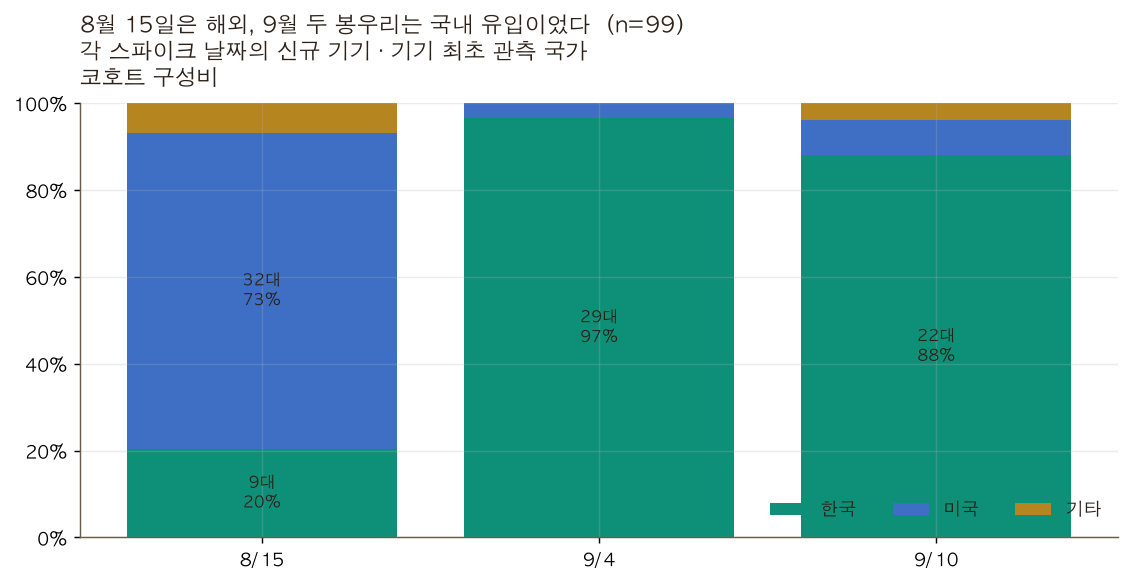

In [4]:
criteria = pd.DataFrame({
    'criterion': ['8/15 해외 ≥60%','8/15 행동 ≤30%','9/4·9/10 한국 각각 ≥50%',
                  '9/4·9/10 행동률이 8/15보다 각각 ≥30%p'],
    'observed': ['79.5%','9.1%','96.7% · 88.0%','+30.9%p · +30.9%p'],
    'pass': [True, True, True, True],
})
display(criteria)
print('H2 판정: 채택')

charts = {}
fig, ax = R.new(
    '8월 15일은 해외, 9월 두 봉우리는 국내 유입이었다', 99,
    sub='각 스파이크 날짜의 신규 기기 · 기기 최초 관측 국가', ylab='코호트 구성비', figsize=(8.8,4.6),
)
country = pd.crosstab(users.cohort, users.country_group).reindex(ORDER[:3])
country = country.reindex(columns=['South Korea','United States','Other'], fill_value=0)
bottom = np.zeros(len(country))
colors = [R.PALETTE[2], R.PALETTE[1], R.PALETTE[3]]
labels = ['한국','미국','기타']
for col, color, label in zip(country.columns, colors, labels):
    vals = country[col].to_numpy() / country.sum(axis=1).to_numpy()
    ax.bar([KO[x] for x in country.index], vals, bottom=bottom, color=color, label=label)
    for i, (v, count) in enumerate(zip(vals, country[col])):
        if v >= .09:
            ax.text(i, bottom[i] + v/2, f'{count}대\n{v:.0%}', ha='center', va='center', fontsize=9)
    bottom += vals
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0,1)
ax.legend(frameon=False, ncol=3)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
charts['country'] = R.save(fig, ax, 'g2_spike_country_composition', zero_base=False)
print(R.check(charts['country'])); display(R.show(charts['country']))

## 5. 의도적 행동률

8/15 행동률 9.1%는 평시 36.6%보다도 낮다. 9/4와 9/10은 각각 40.0%로 평시와 비슷하다. 95% 윌슨 구간이 넓으므로 9/4와 9/10의 순위를 말할 수 없으며, 둘 다 정확히 12/30대와 10/25대다.

g2_spike_action_rate.png  1124x585px


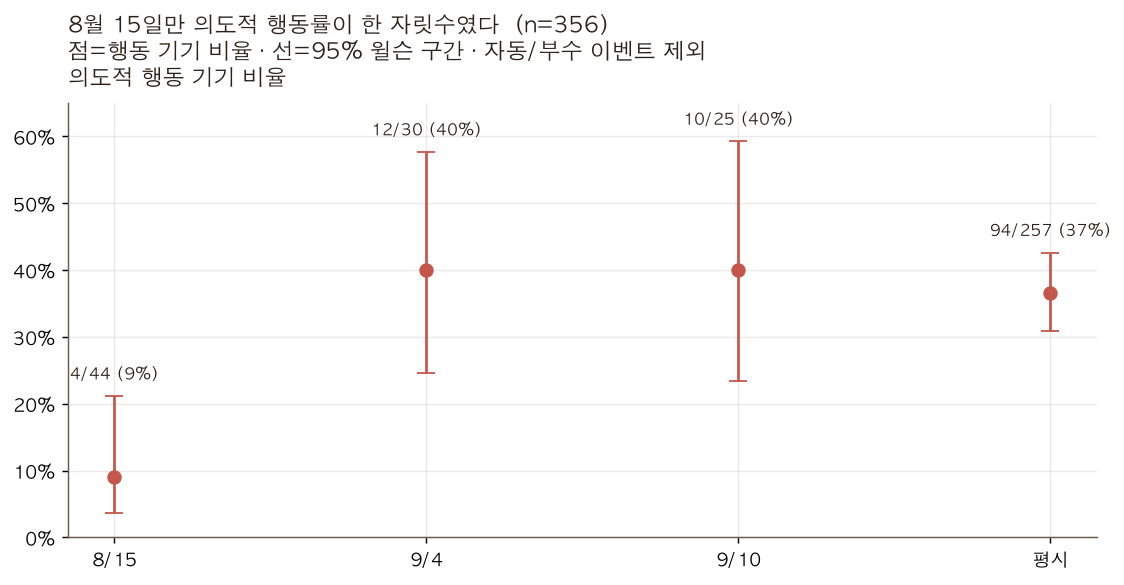

In [5]:
rates=[]
for cohort in ORDER:
    d=users[users.cohort==cohort]
    k=int(d.acted.sum()); n=len(d); lo,hi=wilson(k,n)
    rates.append((cohort,k,n,k/n,lo,hi))
rate_df=pd.DataFrame(rates,columns=['cohort','k','n','rate','lo','hi'])
fig, ax = R.new(
    '8월 15일만 의도적 행동률이 한 자릿수였다', len(users),
    sub='점=행동 기기 비율 · 선=95% 윌슨 구간 · 자동/부수 이벤트 제외', ylab='의도적 행동 기기 비율', figsize=(8.8,4.6),
)
x=np.arange(len(rate_df)); y=rate_df.rate.to_numpy()
err=np.vstack([y-rate_df.lo.to_numpy(),rate_df.hi.to_numpy()-y])
ax.errorbar(x,y,yerr=err,fmt='o',capsize=5,color=R.PALETTE[0],markersize=7)
for i,row in rate_df.iterrows():
    ax.text(i,row.hi+.025,f"{row.k}/{row.n} ({row.rate:.0%})",ha='center',fontsize=9)
ax.set_xticks(x,[KO[c] for c in rate_df.cohort])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(0,.65)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
charts['action_rate']=R.save(fig,ax,'g2_spike_action_rate',zero_base=False)
print(R.check(charts['action_rate'])); display(R.show(charts['action_rate']))

## 6. 행동 깊이

8/15는 44대 중 40대가 의도적 행동 0종이다. 9/4는 12대, 9/10은 10대가 행동했고 그중 4종 이상에 도달한 기기는 각각 5대와 6대다. 9/10의 행동자 수는 더 적지만, 들어온 행동자 일부는 여러 시스템을 건드렸다.

g2_spike_action_depth.png  1131x585px


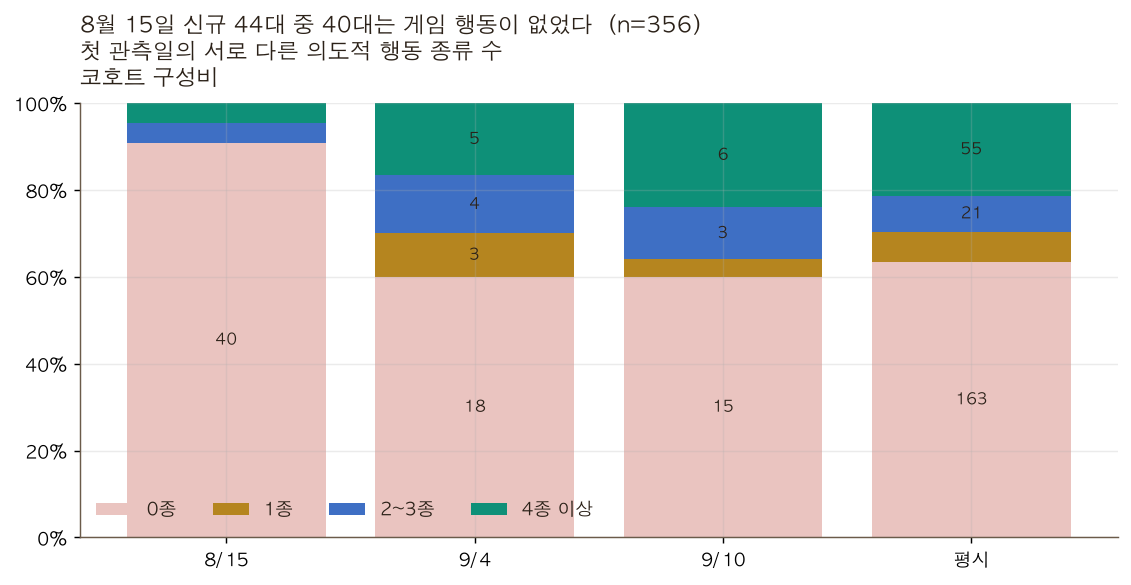

In [6]:
depth=pd.cut(users.deliberate_kinds,[-1,0,1,3,np.inf],labels=['0종','1종','2~3종','4종 이상'])
depth_tab=pd.crosstab(users.cohort,depth).reindex(ORDER).fillna(0)
fig,ax=R.new('8월 15일 신규 44대 중 40대는 게임 행동이 없었다',len(users),
             sub='첫 관측일의 서로 다른 의도적 행동 종류 수',ylab='코호트 구성비',figsize=(8.8,4.6))
bottom=np.zeros(len(depth_tab)); cols=[R.tint(R.PALETTE[0],.65),R.PALETTE[3],R.PALETTE[1],R.PALETTE[2]]
for label,color in zip(depth_tab.columns,cols):
    vals=depth_tab[label].to_numpy()/depth_tab.sum(axis=1).to_numpy()
    ax.bar([KO[x] for x in depth_tab.index],vals,bottom=bottom,label=label,color=color)
    for i,(v,count) in enumerate(zip(vals,depth_tab[label])):
        if v>=.08: ax.text(i,bottom[i]+v/2,str(int(count)),ha='center',va='center',fontsize=9)
    bottom+=vals
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(0,1)
ax.legend(frameon=False,ncol=4); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); charts['depth']=R.save(fig,ax,'g2_spike_action_depth',zero_base=False)
print(R.check(charts['depth'])); display(R.show(charts['depth']))

## 7. 어떤 종류의 행동을 했나

9/4 행동은 자연 채집과 퀘스트가 각각 20%, 고급 콘텐츠가 23%다. 9/10은 자연 채집과 퀘스트가 각각 36%로 더 넓게 퍼졌고 제작·집 24%, 낚시·바다와 고급 콘텐츠가 각각 20%다. 퍼센트는 전체 코호트 중 해당 범주를 한 번이라도 한 기기의 비율이라 합이 100%가 될 필요가 없다.

g2_spike_behavior_categories.png  1120x611px


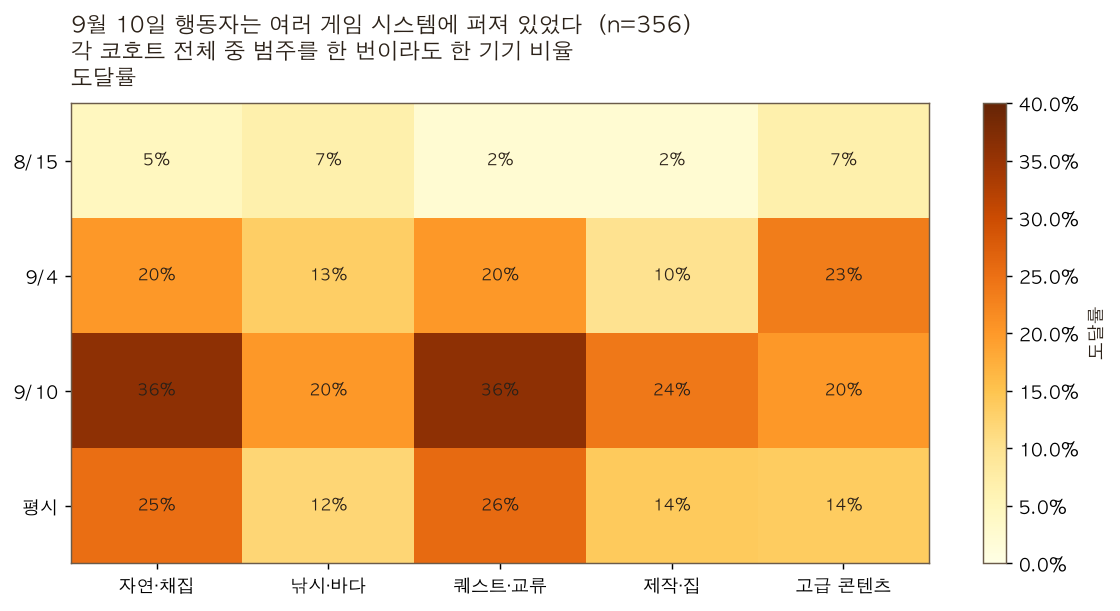

In [7]:
category_cols=['nature_events','fishing_sea_events','quest_social_events','craft_home_events','advanced_events']
category_names=['자연·채집','낚시·바다','퀘스트·교류','제작·집','고급 콘텐츠']
cat=pd.DataFrame(index=ORDER,columns=category_names,dtype=float)
for cohort in ORDER:
    d=users[users.cohort==cohort]
    for col,name in zip(category_cols,category_names): cat.loc[cohort,name]=(d[col]>0).mean()
fig,ax=R.new('9월 10일 행동자는 여러 게임 시스템에 퍼져 있었다',len(users),
             sub='각 코호트 전체 중 범주를 한 번이라도 한 기기 비율',ylab='도달률',figsize=(9,4.8))
im=ax.imshow(cat.to_numpy(),cmap='YlOrBr',vmin=0,vmax=.4,aspect='auto')
ax.set_xticks(range(len(cat.columns)),cat.columns); ax.set_yticks(range(len(cat)),[KO[x] for x in cat.index])
for i in range(len(cat)):
    for j in range(len(cat.columns)):
        ax.text(j,i,f'{cat.iloc[i,j]:.0%}',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=ax,format=mticker.PercentFormatter(1.0),label='도달률')
ax.grid(False); fig.tight_layout(); charts['categories']=R.save(fig,ax,'g2_spike_behavior_categories',zero_base=False)
print(R.check(charts['categories'])); display(R.show(charts['categories']))

## 8. 구체적인 이벤트 지문

세 코호트 전체에서 도달 기기가 많은 행동 12개를 같은 축으로 비교했다. 9/10은 `npc_talk` 36%, `quest_accept` 32%, `plant_seed` 28%가 중심이다. 9/4는 벌목·NPC·퀘스트 수락이 각각 20%다. 8/15는 가장 높은 행동도 `boat_start`와 `mist_purify_start` 각각 6.8%뿐이다.

g2_spike_event_fingerprint.png  1336x572px


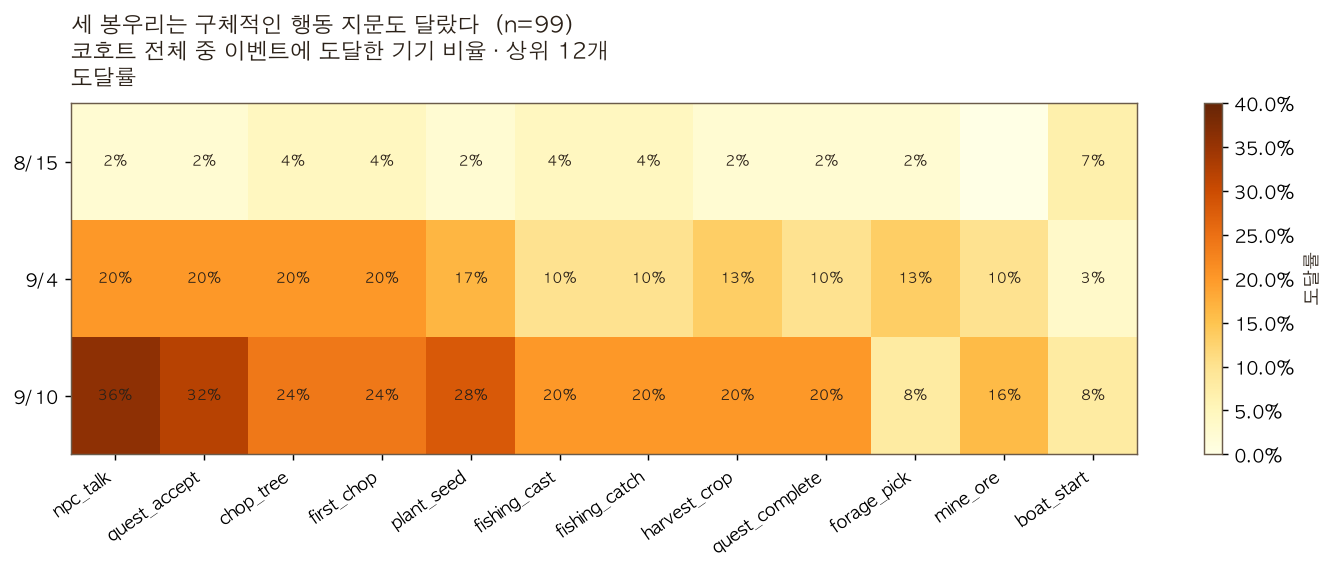

In [8]:
spike_actions=actions[actions.cohort.isin(ORDER[:3])]
top=(spike_actions.groupby('event_name').devices.sum().nlargest(12).index)
finger=(spike_actions[spike_actions.event_name.isin(top)]
        .pivot(index='cohort',columns='event_name',values='reach_pct')
        .reindex(ORDER[:3]).reindex(columns=top).fillna(0)/100)
fig,ax=R.new('세 봉우리는 구체적인 행동 지문도 달랐다',99,
             sub='코호트 전체 중 이벤트에 도달한 기기 비율 · 상위 12개',ylab='도달률',figsize=(11,4.5))
im=ax.imshow(finger.to_numpy(),cmap='YlOrBr',vmin=0,vmax=max(.4,float(finger.max().max())),aspect='auto')
ax.set_xticks(range(len(finger.columns)),finger.columns,rotation=35,ha='right')
ax.set_yticks(range(len(finger)),[KO[x] for x in finger.index])
for i in range(len(finger)):
    for j in range(len(finger.columns)):
        if finger.iloc[i,j]>0: ax.text(j,i,f'{finger.iloc[i,j]:.0%}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,format=mticker.PercentFormatter(1.0),label='도달률')
ax.grid(False); fig.tight_layout(); charts['fingerprint']=R.save(fig,ax,'g2_spike_event_fingerprint',zero_base=False)
print(R.check(charts['fingerprint'])); display(R.show(charts['fingerprint']))

## 9. 기기 유형

9/4 신규는 모바일이 26/30대(86.7%)로 다른 코호트와 확연히 다르다. 8/15는 모바일 19/44대, 9/10은 13/25대다. 다만 국가·날짜·기기가 동시에 바뀌었으므로 “모바일이라 행동했다”는 결론은 낼 수 없다.

g2_spike_device_composition.png  1131x585px


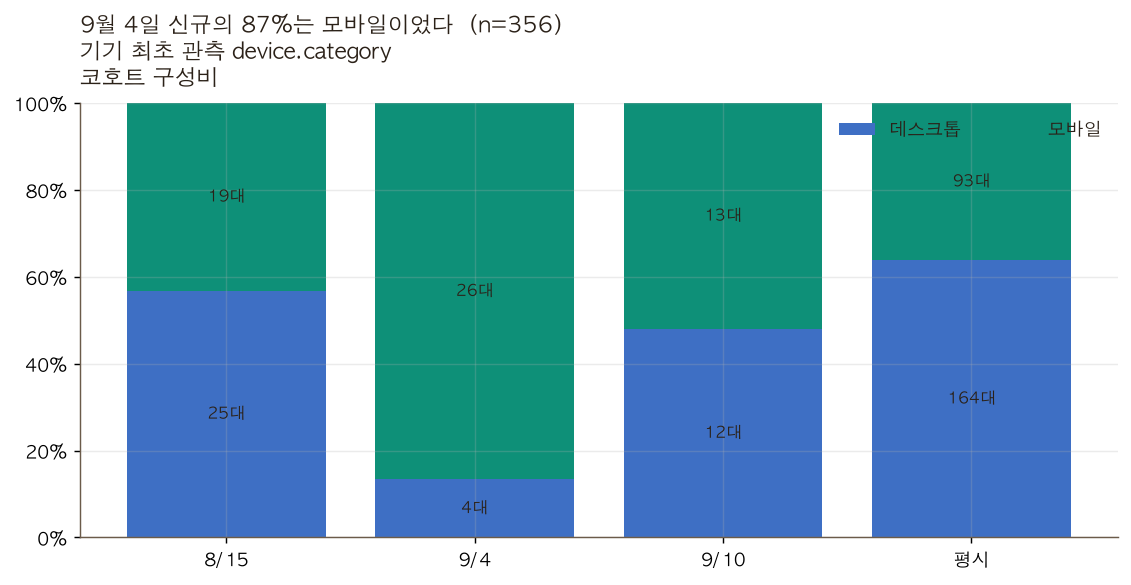

In [9]:
device=pd.crosstab(users.cohort,users.device).reindex(ORDER).reindex(columns=['desktop','mobile'],fill_value=0)
fig,ax=R.new('9월 4일 신규의 87%는 모바일이었다',len(users),
             sub='기기 최초 관측 device.category',ylab='코호트 구성비',figsize=(8.8,4.6))
bottom=np.zeros(len(device))
for col,color,label in [('desktop',R.PALETTE[1],'데스크톱'),('mobile',R.PALETTE[2],'모바일')]:
    vals=device[col].to_numpy()/device.sum(axis=1).to_numpy()
    ax.bar([KO[x] for x in device.index],vals,bottom=bottom,label=label,color=color)
    for i,(v,count) in enumerate(zip(vals,device[col])):
        if v>=.08: ax.text(i,bottom[i]+v/2,f'{count}대',ha='center',va='center',fontsize=9)
    bottom+=vals
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(0,1)
ax.legend(frameon=False,ncol=2); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); charts['device']=R.save(fig,ax,'g2_spike_device_composition',zero_base=False)
print(R.check(charts['device'])); display(R.show(charts['device']))

## 10. 첫날 관측 길이

이는 실제 플레이 시간이 아니라 첫 이벤트부터 마지막 이벤트까지의 간격이다. 8/15 중앙값은 7초, 9/4는 46.5초, 9/10은 54초다. 긴 꼬리가 있어 중앙값만으로는 부족하므로 구간 구성도 함께 본다.

g2_spike_observed_span.png  1131x585px


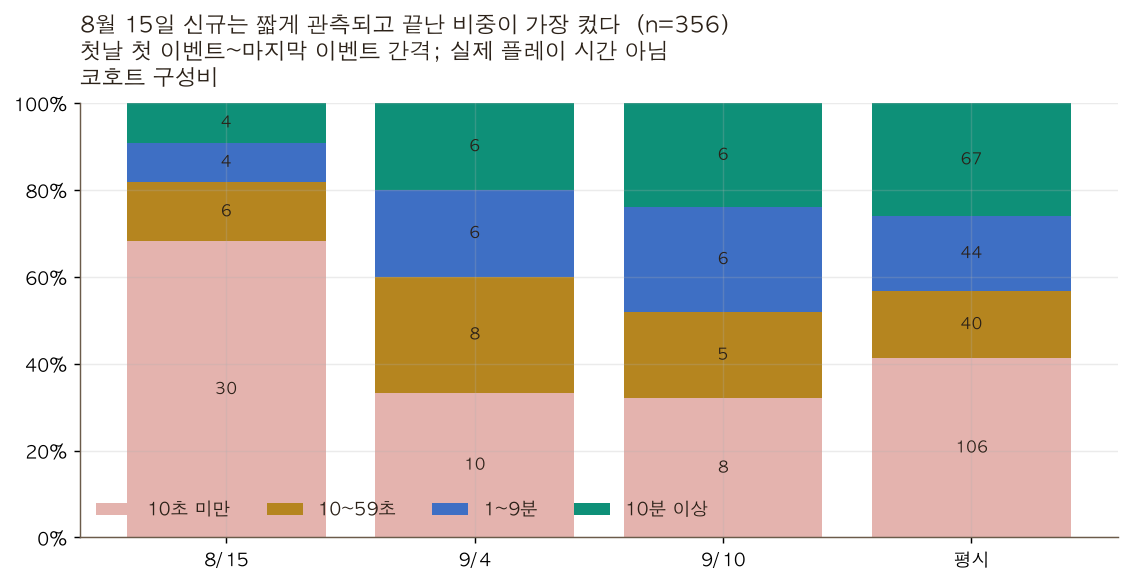

In [10]:
span_bin=pd.cut(users.observed_span_sec,[-1,9,59,599,np.inf],labels=['10초 미만','10~59초','1~9분','10분 이상'])
span=pd.crosstab(users.cohort,span_bin).reindex(ORDER).fillna(0)
fig,ax=R.new('8월 15일 신규는 짧게 관측되고 끝난 비중이 가장 컸다',len(users),
             sub='첫날 첫 이벤트~마지막 이벤트 간격; 실제 플레이 시간 아님',ylab='코호트 구성비',figsize=(8.8,4.6))
bottom=np.zeros(len(span)); colors=[R.tint(R.PALETTE[0],.55),R.PALETTE[3],R.PALETTE[1],R.PALETTE[2]]
for label,color in zip(span.columns,colors):
    vals=span[label].to_numpy()/span.sum(axis=1).to_numpy()
    ax.bar([KO[x] for x in span.index],vals,bottom=bottom,label=label,color=color)
    for i,(v,count) in enumerate(zip(vals,span[label])):
        if v>=.08: ax.text(i,bottom[i]+v/2,str(int(count)),ha='center',va='center',fontsize=9)
    bottom+=vals
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(0,1)
ax.legend(frameon=False,ncol=4); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); charts['span']=R.save(fig,ax,'g2_spike_observed_span',zero_base=False)
print(R.check(charts['span'])); display(R.show(charts['span']))

## 11. D1·D7 재방문

D1은 8/15 2/44대(4.5%), 9/4 4/30대(13.3%), 9/10 1/25대(4.0%)다. 9/4가 높아 보이지만 분자가 4라 구간이 넓고 평시와 겹친다.

D7은 8/15 1/44대, 9/4 1/30대다. 9/10의 D7 관측일은 9월 17일이라 아직 계산할 수 없다. 낮은 D7을 근거로 날짜 순위를 매길 표본이 아니다.

g2_spike_d1_return.png  1131x585px


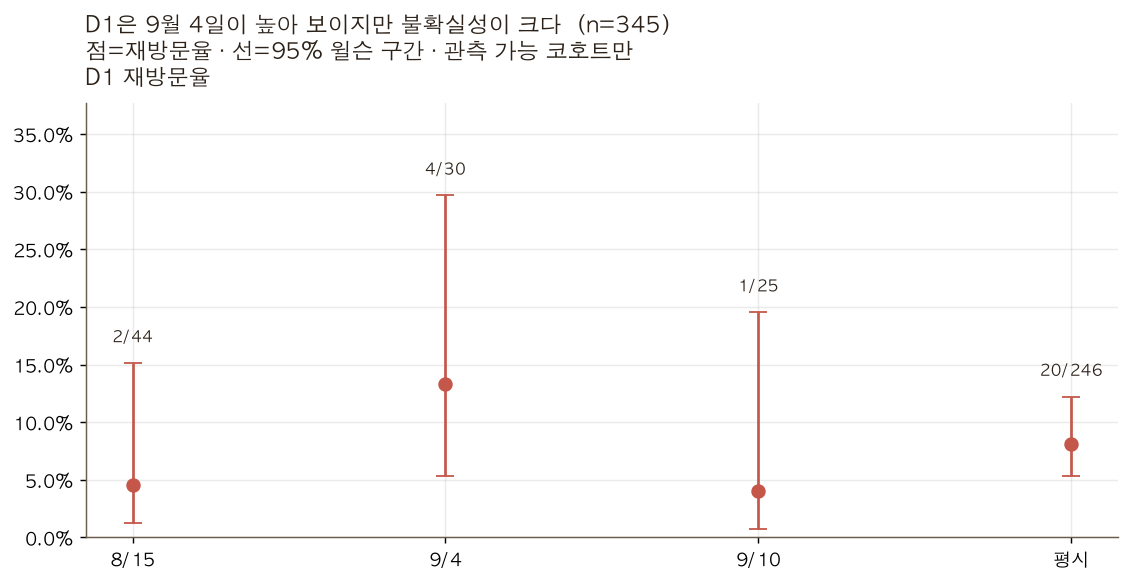

g2_spike_d7_return.png  1131x585px


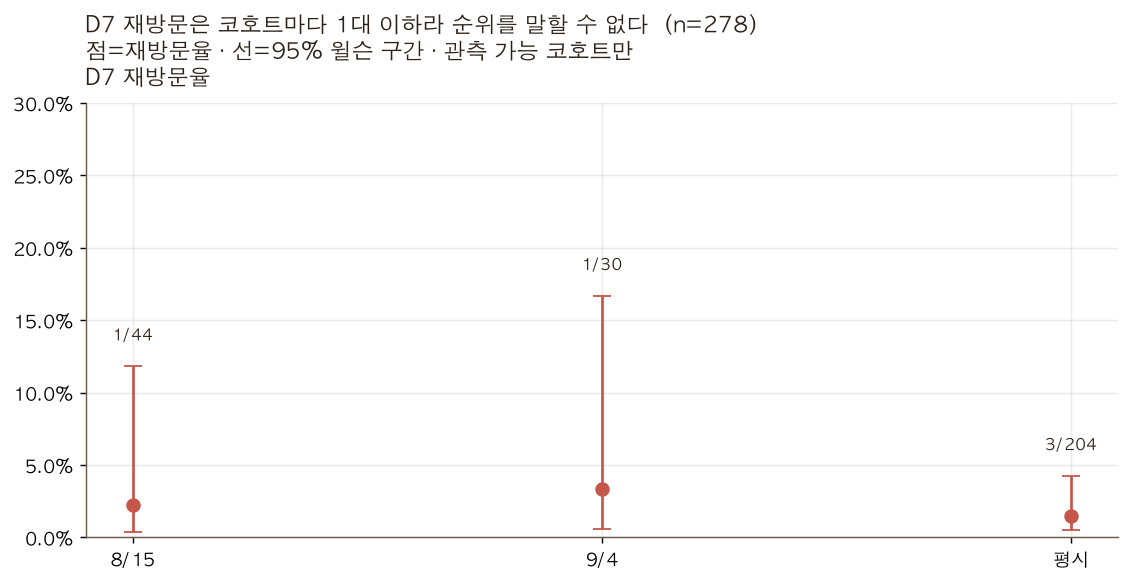

In [11]:
for horizon,title,filename in [
    ('d1','D1은 9월 4일이 높아 보이지만 불확실성이 크다','g2_spike_d1_return'),
    ('d7','D7 재방문은 코호트마다 1대 이하라 순위를 말할 수 없다','g2_spike_d7_return'),
]:
    data=retention[(retention.horizon==horizon)&(retention.eligible>0)].copy()
    x=np.arange(len(data)); y=data.rate.to_numpy()
    err=np.vstack([y-data.lo.to_numpy(),data.hi.to_numpy()-y])
    fig,ax=R.new(title,int(data.eligible.sum()),sub='점=재방문율 · 선=95% 윌슨 구간 · 관측 가능 코호트만',
                 ylab=f'{horizon.upper()} 재방문율',figsize=(8.8,4.6))
    ax.errorbar(x,y,yerr=err,fmt='o',capsize=5,color=R.PALETTE[0],markersize=7)
    for i,row in data.reset_index(drop=True).iterrows():
        ax.text(i,row.hi+.018,f"{int(row.returned)}/{int(row.eligible)}",ha='center',fontsize=9)
    ax.set_xticks(x,[KO[c] for c in data.cohort]); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(0,max(.3,float(data.hi.max()+.08))); ax.spines[['top','right']].set_visible(False)
    fig.tight_layout(); charts[horizon]=R.save(fig,ax,filename,zero_base=False)
    print(R.check(charts[horizon])); display(R.show(charts[horizon]))

## 12. 그래서 크기가 얼마나 되나

- 스파이크 신규는 99대로 전체 356대의 27.8%다.
- 그중 8/15 신규 44대는 해외 35대, 의도적 행동 4대다. DAU 최대 봉우리의 대부분은 게임에 들어오지 않은 트래픽이었다.
- 9/4·9/10 신규 55대는 한국 51대다. 의도적 행동은 22대로 40.0%이며, 평시 36.6%와 비슷하다.
- 9/4는 모바일 중심, 9/10은 기기가 고르게 섞였다. 행동자도 9/4는 벌목·퀘스트, 9/10은 농사·NPC·퀘스트와 여러 후반 시스템으로 더 퍼졌다.
- H2는 사전 기준으로 채택한다. 단, 뒤 두 날짜를 “고관여 다수”로 부르면 과장이다. **국내·상대적 고관여 유입**이 정확하다.

## 13. 이 숫자로 말할 수 없는 것

- 코호트가 25~44대로 작다. 비율의 95% 구간이 넓고 세부 셀은 대부분 10대 미만이다.
- 국가·기기·날짜·게임 버전이 함께 바뀌었다. 어느 한 속성이 행동을 만들었다고 말할 수 없다.
- `user_pseudo_id`는 사람보다 브라우저/기기에 가깝다.
- 허용목록에 없는 실제 행동은 무행동으로 잘못 분류될 수 있다. 반대로 반복 이벤트 수는 플레이 깊이를 과장할 수 있다.
- 평시 코호트는 7/27~9/11 여러 버전을 섞은 참고선이다. 스파이크와 완전히 동일한 노출 조건이 아니다.
- 베타 유급 테스터 표식이 안정적으로 연결되지 않아 9월 국내 유입에 포함됐을 수 있다.
- D7은 9/10에 아직 미성숙하며, 8/15·9/4도 재방문이 각 1대라 효과 비교가 불가능하다.

## 14. 다음에 확인할 것

다음 후보는 **9/4와 9/10 국내 신규 중 행동한 22대가 어떤 첫 진입 경로를 밟았는지**다. 이벤트 순서용 증가 시퀀스가 없어 같은 타임스탬프 안의 정확한 순서는 복원하기 어렵다는 제약부터 해결해야 한다. 이번 노트북에서는 다음 가설이나 모델링을 시작하지 않는다.

## 15. W&B 기록

집계표와 PNG만 기록하며 사용자 식별자는 업로드하지 않는다. 같은 노트북을 다시 실행하면 기존 run을 이어 쓴다.

In [12]:
run_file=OUT/'wandb_run_id.txt'
kwargs={'project':tracking.PROJECT}
if run_file.exists(): kwargs.update(id=run_file.read_text().strip(),resume='must')
else: kwargs.update(name='g2-spike-behavior-eda',tags=['gate','eda','spike-cohort'])
with tracking.wandb.init(**kwargs) as run:
    run.summary['spike_devices']=99
    run.summary['aug15_action_rate']=4/44
    run.summary['sep04_action_rate']=12/30
    run.summary['sep10_action_rate']=10/25
    run.summary['aug15_overseas_rate']=35/44
    run.summary['sep04_korea_rate']=29/30
    run.summary['sep10_korea_rate']=22/25
    run.summary['h2_result']='accepted'
    run.log({k:tracking.wandb.Image(str(v)) for k,v in charts.items()})
    artifact=tracking.wandb.Artifact('g2-spike-behavior-eda',type='analysis')
    for p in OUT.glob('*.csv'): artifact.add_file(str(p))
    for name in sql_files: artifact.add_file(str(SQL/name),name=f'sql/{name}')
    for p in charts.values(): artifact.add_file(str(p),name=f'figs/{p.name}')
    run.log_artifact(artifact)
    run_file.write_text(run.id,encoding='utf-8')
    print('W&B run:',run.url); print('W&B run id:',run.id)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: icucheol to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run o1ywyrop


wandb: Tracking run with wandb version 0.28.2


wandb: Run data is saved locally in /Users/uicheol_hwang/calm_forest/wandb/run-20260912_201425-o1ywyrop
wandb: Run `wandb offline` to turn off syncing.


...

wandb: uploading media/images/country_0_8b34cab97ccb493cdf25.png; uploading media/images/depth_0_e35bf02ed38d4bf76c1a.png; uploading media/images/categories_0_643d266aa7ecff73c44b.png; uploading config.yaml; uploading requirements.txt (+ 8 more)


wandb: uploading history steps 0-0, summary


wandb: 
wandb: Run summary:
wandb:   aug15_action_rate 0.09091
wandb: aug15_overseas_rate 0.79545
wandb:           h2_result accepted
wandb:   sep04_action_rate 0.4
wandb:    sep04_korea_rate 0.96667
wandb:   sep10_action_rate 0.4
wandb:    sep10_korea_rate 0.88
wandb:       spike_devices 99
wandb: 


wandb: 🚀 View run g2-spike-behavior-eda at: https://wandb.ai/icucheol/calm-forest/runs/o1ywyrop
wandb: ⭐️ View project at: https://wandb.ai/icucheol/calm-forest
wandb: Synced 4 W&B file(s), 9 media file(s), 16 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260912_201425-o1ywyrop/logs
